In [1]:
# Cell 1 - Import dan konfigurasi path

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x


# ============================================================
# PATH CONFIG
# ============================================================

FRAMED_BASE_DIR = Path("/media/spell/Spell-lab/Lidar/Framed Dataset")

RAW_DEV_DIR = FRAMED_BASE_DIR / "Dataset Development"
RAW_TEST_DIR = FRAMED_BASE_DIR / "Dataset Testing"

# Sesuaikan dengan folder output preprocessing kamu.
# Kalau output kamu masih memakai Z008, biarkan seperti ini.
# Kalau sudah kamu ubah ke Z080, ganti sesuai folder aktual.
PREPROC_BASE_DIR = Path("/media/spell/Spell-lab/Lidar/Preprocessing") / "Preprocessed_GC25_Z008"

GC_ROI_DIR = PREPROC_BASE_DIR / "GC25_ROI"
GC_ZT_DIR = PREPROC_BASE_DIR / "GC25_Z080"

METRICS_DIR = PREPROC_BASE_DIR / "_metrics"
DIAG_DIR = PREPROC_BASE_DIR / "_diagnostics"
FIG_DIR = DIAG_DIR / "figures"

DIAG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# PARAMETER YANG SEDANG DIAUDIT
# ============================================================

GC_ANGLE_DEG = 25.0
Z_GROUND_THRESHOLD = 0.08

ROI_X_MIN, ROI_X_MAX = 0.0, 3.0
ROI_Y_MIN, ROI_Y_MAX = -1.5, 1.5
ROI_Z_MIN, ROI_Z_MAX = 0.0, 2.0

LOW_Z_RESIDUAL_LIMIT = 0.15


# ============================================================
# DATASET CONFIG
# ============================================================

ACTIVITIES = ["Bungkuk", "Duduk", "Jongkok", "Jatuh"]

DEV_SUBJECTS = [
    "Adelia", "Afi", "Aswangga", "Bustan", "Dilia", "Eldivo",
    "Fathir", "Lina", "Manda", "Miftah", "Teguh", "Tsamara",
]

TEST_ROOMS = ["Controlled Room", "Uncontrolled Room"]

TEST_SUBJECTS = [
    "Kanaya", "Naila", "Nana", "Rega", "Zaira",
]

FILE_IDS = list(range(1, 10))

REQUIRED_OUTPUT_COLUMNS = [
    "frame_id", "Timestamp",
    "X", "Y", "Z",
    "X_corr", "Y_corr", "Z_corr", "Z_level",
    "Reflectivity",
]

print("===== DIAGNOSTIC CONFIG =====")
print(f"Raw framed base : {FRAMED_BASE_DIR}")
print(f"Preproc base    : {PREPROC_BASE_DIR}")
print(f"GC ROI dir      : {GC_ROI_DIR}")
print(f"GC ZT dir       : {GC_ZT_DIR}")
print(f"Diagnostic dir  : {DIAG_DIR}")
print(f"GC angle        : {GC_ANGLE_DEG} degree")
print(f"Z threshold     : {Z_GROUND_THRESHOLD} m")

===== DIAGNOSTIC CONFIG =====
Raw framed base : /media/spell/Spell-lab/Lidar/Framed Dataset
Preproc base    : /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008
GC ROI dir      : /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/GC25_ROI
GC ZT dir       : /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/GC25_Z080
Diagnostic dir  : /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics
GC angle        : 25.0 degree
Z threshold     : 0.08 m


In [2]:
# Cell 2 - Buat manifest raw, ROI, dan Z-threshold output

def build_manifest():
    records = []

    # Development
    for activity in ACTIVITIES:
        for subject in DEV_SUBJECTS:
            for file_id in FILE_IDS:
                rel_path = Path("Dataset Development") / activity / subject / f"{file_id}.csv"

                records.append({
                    "split": "development",
                    "room": "development",
                    "activity": activity,
                    "subject": subject,
                    "file_id": file_id,
                    "rel_path": rel_path,
                    "raw_path": FRAMED_BASE_DIR / rel_path,
                    "roi_path": GC_ROI_DIR / rel_path,
                    "zt_path": GC_ZT_DIR / rel_path,
                })

    # Testing
    for room in TEST_ROOMS:
        for activity in ACTIVITIES:
            for subject in TEST_SUBJECTS:
                for file_id in FILE_IDS:
                    rel_path = Path("Dataset Testing") / room / activity / subject / f"{file_id}.csv"

                    records.append({
                        "split": "testing",
                        "room": room,
                        "activity": activity,
                        "subject": subject,
                        "file_id": file_id,
                        "rel_path": rel_path,
                        "raw_path": FRAMED_BASE_DIR / rel_path,
                        "roi_path": GC_ROI_DIR / rel_path,
                        "zt_path": GC_ZT_DIR / rel_path,
                    })

    df = pd.DataFrame(records)

    df["raw_exists"] = df["raw_path"].apply(lambda p: Path(p).exists())
    df["roi_exists"] = df["roi_path"].apply(lambda p: Path(p).exists())
    df["zt_exists"] = df["zt_path"].apply(lambda p: Path(p).exists())

    return df


manifest_df = build_manifest()

manifest_save_path = DIAG_DIR / "diagnostic_manifest.csv"
manifest_df.assign(
    rel_path=manifest_df["rel_path"].astype(str),
    raw_path=manifest_df["raw_path"].astype(str),
    roi_path=manifest_df["roi_path"].astype(str),
    zt_path=manifest_df["zt_path"].astype(str),
).to_csv(manifest_save_path, index=False)

print("===== MANIFEST CHECK =====")
print(f"Total expected files : {len(manifest_df):,}")
print(f"Raw exists           : {manifest_df['raw_exists'].sum():,}")
print(f"GC ROI exists        : {manifest_df['roi_exists'].sum():,}")
print(f"GC ZT exists         : {manifest_df['zt_exists'].sum():,}")
print(f"Saved manifest       : {manifest_save_path}")

display(manifest_df.head())

===== MANIFEST CHECK =====
Total expected files : 792
Raw exists           : 792
GC ROI exists        : 792
GC ZT exists         : 792
Saved manifest       : /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/diagnostic_manifest.csv


,split,room,activity,subject,file_id,rel_path,raw_path,roi_path,zt_path,raw_exists,roi_exists,zt_exists
0,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,/media/spell/Spell-lab/Lidar/Framed Dataset/Da...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,True,True,True
1,development,development,Bungkuk,Adelia,2,Dataset Development/Bungkuk/Adelia/2.csv,/media/spell/Spell-lab/Lidar/Framed Dataset/Da...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,True,True,True
2,development,development,Bungkuk,Adelia,3,Dataset Development/Bungkuk/Adelia/3.csv,/media/spell/Spell-lab/Lidar/Framed Dataset/Da...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,True,True,True
3,development,development,Bungkuk,Adelia,4,Dataset Development/Bungkuk/Adelia/4.csv,/media/spell/Spell-lab/Lidar/Framed Dataset/Da...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,True,True,True
4,development,development,Bungkuk,Adelia,5,Dataset Development/Bungkuk/Adelia/5.csv,/media/spell/Spell-lab/Lidar/Framed Dataset/Da...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,/media/spell/Spell-lab/Lidar/Preprocessing/Pre...,True,True,True


In [3]:
# Cell 3 - Fungsi utilitas diagnostik

def safe_read_csv(path: Path):
    try:
        if not Path(path).exists():
            return None, "missing"
        df = pd.read_csv(path)
        return df, ""
    except Exception as e:
        return None, str(e)


def safe_range(series):
    if series is None or len(series) == 0:
        return np.nan, np.nan, np.nan
    return float(series.min()), float(series.max()), float(series.max() - series.min())


def safe_ratio(num, den):
    if den is None or den == 0 or pd.isna(den):
        return np.nan
    return num / den


def check_required_columns(df, required_cols):
    if df is None:
        return False, required_cols
    missing = [c for c in required_cols if c not in df.columns]
    return len(missing) == 0, missing


def get_frame_count(df):
    if df is None or len(df) == 0 or "frame_id" not in df.columns:
        return 0
    return int(df["frame_id"].nunique())


def get_point_count(df):
    if df is None:
        return np.nan
    return int(len(df))


def compute_basic_file_stats(df, prefix):
    if df is None or len(df) == 0:
        return {
            f"{prefix}_points": 0 if df is not None else np.nan,
            f"{prefix}_frames": 0,
            f"{prefix}_x_min": np.nan,
            f"{prefix}_x_max": np.nan,
            f"{prefix}_x_range": np.nan,
            f"{prefix}_y_min": np.nan,
            f"{prefix}_y_max": np.nan,
            f"{prefix}_y_range": np.nan,
            f"{prefix}_z_min": np.nan,
            f"{prefix}_z_max": np.nan,
            f"{prefix}_z_range": np.nan,
        }

    # raw pakai X/Y/Z, output pakai X_corr/Y_corr/Z_level
    if prefix == "raw":
        x_col, y_col, z_col = "X", "Y", "Z"
    else:
        x_col, y_col, z_col = "X_corr", "Y_corr", "Z_level"

    x_min, x_max, x_range = safe_range(df[x_col]) if x_col in df.columns else (np.nan, np.nan, np.nan)
    y_min, y_max, y_range = safe_range(df[y_col]) if y_col in df.columns else (np.nan, np.nan, np.nan)
    z_min, z_max, z_range = safe_range(df[z_col]) if z_col in df.columns else (np.nan, np.nan, np.nan)

    return {
        f"{prefix}_points": int(len(df)),
        f"{prefix}_frames": get_frame_count(df),
        f"{prefix}_x_min": x_min,
        f"{prefix}_x_max": x_max,
        f"{prefix}_x_range": x_range,
        f"{prefix}_y_min": y_min,
        f"{prefix}_y_max": y_max,
        f"{prefix}_y_range": y_range,
        f"{prefix}_z_min": z_min,
        f"{prefix}_z_max": z_max,
        f"{prefix}_z_range": z_range,
    }


def compute_height_distribution(df, prefix):
    if df is None or len(df) == 0:
        return {
            f"{prefix}_z_p01": np.nan,
            f"{prefix}_z_p05": np.nan,
            f"{prefix}_z_p25": np.nan,
            f"{prefix}_z_p50": np.nan,
            f"{prefix}_z_p75": np.nan,
            f"{prefix}_z_p95": np.nan,
            f"{prefix}_z_p99": np.nan,
            f"{prefix}_z_mean": np.nan,
            f"{prefix}_z_std": np.nan,
        }

    z_col = "Z" if prefix == "raw" else "Z_level"
    if z_col not in df.columns:
        return {
            f"{prefix}_z_p01": np.nan,
            f"{prefix}_z_p05": np.nan,
            f"{prefix}_z_p25": np.nan,
            f"{prefix}_z_p50": np.nan,
            f"{prefix}_z_p75": np.nan,
            f"{prefix}_z_p95": np.nan,
            f"{prefix}_z_p99": np.nan,
            f"{prefix}_z_mean": np.nan,
            f"{prefix}_z_std": np.nan,
        }

    z = df[z_col].dropna().to_numpy()

    if len(z) == 0:
        return {
            f"{prefix}_z_p01": np.nan,
            f"{prefix}_z_p05": np.nan,
            f"{prefix}_z_p25": np.nan,
            f"{prefix}_z_p50": np.nan,
            f"{prefix}_z_p75": np.nan,
            f"{prefix}_z_p95": np.nan,
            f"{prefix}_z_p99": np.nan,
            f"{prefix}_z_mean": np.nan,
            f"{prefix}_z_std": np.nan,
        }

    return {
        f"{prefix}_z_p01": float(np.percentile(z, 1)),
        f"{prefix}_z_p05": float(np.percentile(z, 5)),
        f"{prefix}_z_p25": float(np.percentile(z, 25)),
        f"{prefix}_z_p50": float(np.percentile(z, 50)),
        f"{prefix}_z_p75": float(np.percentile(z, 75)),
        f"{prefix}_z_p95": float(np.percentile(z, 95)),
        f"{prefix}_z_p99": float(np.percentile(z, 99)),
        f"{prefix}_z_mean": float(np.mean(z)),
        f"{prefix}_z_std": float(np.std(z)),
    }

In [4]:
# Cell 4 - Diagnostik per file: raw vs GC_ROI vs GC_ZT

file_diag_records = []

for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc="Diagnosing files"):
    raw_df, raw_err = safe_read_csv(row["raw_path"])
    roi_df, roi_err = safe_read_csv(row["roi_path"])
    zt_df, zt_err = safe_read_csv(row["zt_path"])

    roi_col_ok, roi_missing_cols = check_required_columns(roi_df, REQUIRED_OUTPUT_COLUMNS) if roi_df is not None else (False, REQUIRED_OUTPUT_COLUMNS)
    zt_col_ok, zt_missing_cols = check_required_columns(zt_df, REQUIRED_OUTPUT_COLUMNS) if zt_df is not None else (False, REQUIRED_OUTPUT_COLUMNS)

    record = {
        "split": row["split"],
        "room": row["room"],
        "activity": row["activity"],
        "subject": row["subject"],
        "file_id": row["file_id"],
        "rel_path": str(row["rel_path"]),

        "raw_exists": row["raw_exists"],
        "roi_exists": row["roi_exists"],
        "zt_exists": row["zt_exists"],

        "raw_error": raw_err,
        "roi_error": roi_err,
        "zt_error": zt_err,

        "roi_columns_ok": roi_col_ok,
        "roi_missing_columns": ",".join(roi_missing_cols) if roi_missing_cols else "",
        "zt_columns_ok": zt_col_ok,
        "zt_missing_columns": ",".join(zt_missing_cols) if zt_missing_cols else "",
    }

    record.update(compute_basic_file_stats(raw_df, "raw"))
    record.update(compute_basic_file_stats(roi_df, "roi"))
    record.update(compute_basic_file_stats(zt_df, "zt"))

    record.update(compute_height_distribution(raw_df, "raw"))
    record.update(compute_height_distribution(roi_df, "roi"))
    record.update(compute_height_distribution(zt_df, "zt"))

    # Retention ratios
    record["roi_retained_ratio_from_raw"] = safe_ratio(record["roi_points"], record["raw_points"])
    record["zt_retained_ratio_from_roi"] = safe_ratio(record["zt_points"], record["roi_points"])
    record["zt_retained_ratio_from_raw"] = safe_ratio(record["zt_points"], record["raw_points"])

    # Empty flags
    record["empty_after_roi"] = int(record["roi_points"] == 0) if not pd.isna(record["roi_points"]) else np.nan
    record["empty_after_zt"] = int(record["zt_points"] == 0) if not pd.isna(record["zt_points"]) else np.nan

    # Low-Z residual after ZT
    if zt_df is not None and len(zt_df) > 0 and "Z_level" in zt_df.columns:
        low_mask = zt_df["Z_level"] <= LOW_Z_RESIDUAL_LIMIT
        low_df = zt_df.loc[low_mask]

        record["zt_low_z_residual_count"] = int(len(low_df))
        record["zt_low_z_residual_ratio"] = safe_ratio(len(low_df), len(zt_df))

        if len(low_df) > 0:
            lx_min, lx_max, lx_range = safe_range(low_df["X_corr"])
            ly_min, ly_max, ly_range = safe_range(low_df["Y_corr"])
        else:
            lx_min, lx_max, lx_range = np.nan, np.nan, np.nan
            ly_min, ly_max, ly_range = np.nan, np.nan, np.nan

        record["zt_low_z_x_min"] = lx_min
        record["zt_low_z_x_max"] = lx_max
        record["zt_low_z_x_range"] = lx_range
        record["zt_low_z_y_min"] = ly_min
        record["zt_low_z_y_max"] = ly_max
        record["zt_low_z_y_range"] = ly_range
    else:
        record["zt_low_z_residual_count"] = 0
        record["zt_low_z_residual_ratio"] = np.nan
        record["zt_low_z_x_min"] = np.nan
        record["zt_low_z_x_max"] = np.nan
        record["zt_low_z_x_range"] = np.nan
        record["zt_low_z_y_min"] = np.nan
        record["zt_low_z_y_max"] = np.nan
        record["zt_low_z_y_range"] = np.nan

    file_diag_records.append(record)


file_diag_df = pd.DataFrame(file_diag_records)

file_diag_path = DIAG_DIR / "gc_zt_file_diagnostic.csv"
file_diag_df.to_csv(file_diag_path, index=False)

print("===== FILE DIAGNOSTIC SAVED =====")
print(file_diag_path)

display(file_diag_df.head())

Diagnosing files:   0%|          | 0/792 [00:00<?, ?it/s]

===== FILE DIAGNOSTIC SAVED =====
/media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_file_diagnostic.csv


,split,room,activity,subject,file_id,rel_path,raw_exists,roi_exists,zt_exists,raw_error,...,empty_after_roi,empty_after_zt,zt_low_z_residual_count,zt_low_z_residual_ratio,zt_low_z_x_min,zt_low_z_x_max,zt_low_z_x_range,zt_low_z_y_min,zt_low_z_y_max,zt_low_z_y_range
0,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,True,True,True,,...,0,0,313,0.004809,1.111803,1.730381,0.618578,0.440,1.120,0.680
1,development,development,Bungkuk,Adelia,2,Dataset Development/Bungkuk/Adelia/2.csv,True,True,True,,...,0,0,275,0.004107,1.111803,1.730381,0.618578,-0.346,1.062,1.408
2,development,development,Bungkuk,Adelia,3,Dataset Development/Bungkuk/Adelia/3.csv,True,True,True,,...,0,0,312,0.004861,1.111803,1.730381,0.618578,-0.915,1.062,1.977
3,development,development,Bungkuk,Adelia,4,Dataset Development/Bungkuk/Adelia/4.csv,True,True,True,,...,0,0,851,0.013789,1.111803,1.924001,0.812198,0.351,1.062,0.711
4,development,development,Bungkuk,Adelia,5,Dataset Development/Bungkuk/Adelia/5.csv,True,True,True,,...,0,0,891,0.014651,1.111803,1.844007,0.732204,-0.348,1.062,1.410


In [5]:
# Cell 5 - Ringkasan global file diagnostic

global_diag = {
    "total_files": len(file_diag_df),
    "raw_exists": int(file_diag_df["raw_exists"].sum()),
    "roi_exists": int(file_diag_df["roi_exists"].sum()),
    "zt_exists": int(file_diag_df["zt_exists"].sum()),

    "empty_after_roi_files": int(file_diag_df["empty_after_roi"].sum()),
    "empty_after_zt_files": int(file_diag_df["empty_after_zt"].sum()),

    "empty_after_roi_file_ratio": float(file_diag_df["empty_after_roi"].mean()),
    "empty_after_zt_file_ratio": float(file_diag_df["empty_after_zt"].mean()),

    "raw_points_total": int(file_diag_df["raw_points"].sum(skipna=True)),
    "roi_points_total": int(file_diag_df["roi_points"].sum(skipna=True)),
    "zt_points_total": int(file_diag_df["zt_points"].sum(skipna=True)),
}

global_diag["roi_retained_ratio_from_raw_weighted"] = safe_ratio(
    global_diag["roi_points_total"],
    global_diag["raw_points_total"]
)

global_diag["zt_retained_ratio_from_roi_weighted"] = safe_ratio(
    global_diag["zt_points_total"],
    global_diag["roi_points_total"]
)

global_diag["zt_retained_ratio_from_raw_weighted"] = safe_ratio(
    global_diag["zt_points_total"],
    global_diag["raw_points_total"]
)

global_diag_df = pd.DataFrame([global_diag])

global_diag_path = DIAG_DIR / "gc_zt_global_diagnostic.csv"
global_diag_df.to_csv(global_diag_path, index=False)

print("===== GLOBAL DIAGNOSTIC =====")
display(global_diag_df)

print(f"Saved: {global_diag_path}")

===== GLOBAL DIAGNOSTIC =====


,total_files,raw_exists,roi_exists,zt_exists,empty_after_roi_files,empty_after_zt_files,empty_after_roi_file_ratio,empty_after_zt_file_ratio,raw_points_total,roi_points_total,zt_points_total,roi_retained_ratio_from_raw_weighted,zt_retained_ratio_from_roi_weighted,zt_retained_ratio_from_raw_weighted
0,792,792,792,792,0,0,0.0,0.0,945984000,97110618,44434255,0.102656,0.457563,0.046971


Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_global_diagnostic.csv


In [6]:
# Cell 6 - Ringkasan per activity

activity_diag = file_diag_df.groupby("activity").agg(
    n_files=("rel_path", "count"),

    raw_points_total=("raw_points", "sum"),
    roi_points_total=("roi_points", "sum"),
    zt_points_total=("zt_points", "sum"),

    roi_retained_ratio_mean=("roi_retained_ratio_from_raw", "mean"),
    zt_retained_ratio_from_roi_mean=("zt_retained_ratio_from_roi", "mean"),
    zt_retained_ratio_from_raw_mean=("zt_retained_ratio_from_raw", "mean"),

    empty_after_roi_ratio=("empty_after_roi", "mean"),
    empty_after_zt_ratio=("empty_after_zt", "mean"),

    roi_z_p50_mean=("roi_z_p50", "mean"),
    roi_z_p95_mean=("roi_z_p95", "mean"),
    zt_z_p50_mean=("zt_z_p50", "mean"),
    zt_z_p95_mean=("zt_z_p95", "mean"),

    zt_low_z_residual_ratio_mean=("zt_low_z_residual_ratio", "mean"),
    zt_low_z_x_range_mean=("zt_low_z_x_range", "mean"),
    zt_low_z_y_range_mean=("zt_low_z_y_range", "mean"),
).reset_index()

activity_diag["roi_retained_ratio_weighted"] = (
    activity_diag["roi_points_total"] / activity_diag["raw_points_total"].replace(0, np.nan)
)

activity_diag["zt_retained_ratio_from_roi_weighted"] = (
    activity_diag["zt_points_total"] / activity_diag["roi_points_total"].replace(0, np.nan)
)

activity_diag_path = DIAG_DIR / "gc_zt_diagnostic_by_activity.csv"
activity_diag.to_csv(activity_diag_path, index=False)

print("===== DIAGNOSTIC BY ACTIVITY =====")
display(activity_diag)

print(f"Saved: {activity_diag_path}")

===== DIAGNOSTIC BY ACTIVITY =====


,activity,n_files,raw_points_total,roi_points_total,zt_points_total,roi_retained_ratio_mean,zt_retained_ratio_from_roi_mean,zt_retained_ratio_from_raw_mean,empty_after_roi_ratio,empty_after_zt_ratio,roi_z_p50_mean,roi_z_p95_mean,zt_z_p50_mean,zt_z_p95_mean,zt_low_z_residual_ratio_mean,zt_low_z_x_range_mean,zt_low_z_y_range_mean,roi_retained_ratio_weighted,zt_retained_ratio_from_roi_weighted
0,Bungkuk,198,230730240,24047141,10922904,0.104302,0.451574,0.047496,0.0,0.0,0.105115,1.021342,0.886962,1.178353,0.010304,1.350784,2.014703,0.104222,0.454229
1,Duduk,198,231109632,24719758,12199865,0.107419,0.491011,0.053332,0.0,0.0,0.209617,1.057996,0.875158,1.199453,0.011638,1.446915,2.000112,0.106961,0.493527
2,Jatuh,198,248901120,24595297,10789697,0.098910,0.436389,0.043510,0.0,0.0,0.092699,0.980278,0.872354,1.147328,0.042889,1.669285,2.400354,0.098816,0.438689
3,Jongkok,198,235243008,23748422,10521789,0.100915,0.440390,0.044743,0.0,0.0,0.090232,0.997100,0.871869,1.199970,0.017658,1.635478,2.294118,0.100953,0.443052


Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_diagnostic_by_activity.csv


In [7]:
# Cell 7 - Ringkasan per posisi / file_id 1 sampai 9

position_diag = file_diag_df.groupby("file_id").agg(
    n_files=("rel_path", "count"),

    raw_points_total=("raw_points", "sum"),
    roi_points_total=("roi_points", "sum"),
    zt_points_total=("zt_points", "sum"),

    roi_retained_ratio_mean=("roi_retained_ratio_from_raw", "mean"),
    zt_retained_ratio_from_roi_mean=("zt_retained_ratio_from_roi", "mean"),
    zt_retained_ratio_from_raw_mean=("zt_retained_ratio_from_raw", "mean"),

    empty_after_roi_ratio=("empty_after_roi", "mean"),
    empty_after_zt_ratio=("empty_after_zt", "mean"),

    roi_x_range_mean=("roi_x_range", "mean"),
    roi_y_range_mean=("roi_y_range", "mean"),
    roi_z_range_mean=("roi_z_range", "mean"),

    zt_x_range_mean=("zt_x_range", "mean"),
    zt_y_range_mean=("zt_y_range", "mean"),
    zt_z_range_mean=("zt_z_range", "mean"),

    zt_low_z_residual_ratio_mean=("zt_low_z_residual_ratio", "mean"),
    zt_low_z_x_range_mean=("zt_low_z_x_range", "mean"),
    zt_low_z_y_range_mean=("zt_low_z_y_range", "mean"),
).reset_index()

position_diag["roi_retained_ratio_weighted"] = (
    position_diag["roi_points_total"] / position_diag["raw_points_total"].replace(0, np.nan)
)

position_diag["zt_retained_ratio_from_roi_weighted"] = (
    position_diag["zt_points_total"] / position_diag["roi_points_total"].replace(0, np.nan)
)

position_diag_path = DIAG_DIR / "gc_zt_diagnostic_by_position.csv"
position_diag.to_csv(position_diag_path, index=False)

print("===== DIAGNOSTIC BY POSITION / FILE_ID =====")
display(position_diag)

print(f"Saved: {position_diag_path}")

===== DIAGNOSTIC BY POSITION / FILE_ID =====


,file_id,n_files,raw_points_total,roi_points_total,zt_points_total,roi_retained_ratio_mean,zt_retained_ratio_from_roi_mean,zt_retained_ratio_from_raw_mean,empty_after_roi_ratio,empty_after_zt_ratio,...,roi_y_range_mean,roi_z_range_mean,zt_x_range_mean,zt_y_range_mean,zt_z_range_mean,zt_low_z_residual_ratio_mean,zt_low_z_x_range_mean,zt_low_z_y_range_mean,roi_retained_ratio_weighted,zt_retained_ratio_from_roi_weighted
0,1,88,103633920,10997011,5305287,0.106232,0.480839,0.051357,0.0,0.0,...,2.999977,1.635466,2.598939,2.188716,1.550597,0.014583,1.468951,2.015674,0.106114,0.482430
1,2,88,105191424,11629785,6245206,0.110559,0.532917,0.059320,0.0,0.0,...,2.999989,1.582418,2.564363,2.213739,1.494806,0.010403,1.379085,2.031341,0.110558,0.537001
2,3,88,103633920,11062399,5230975,0.106922,0.472231,0.050774,0.0,0.0,...,3.000000,1.625787,2.462115,2.488068,1.539872,0.013834,1.295561,2.181047,0.106745,0.472861
3,4,88,104851968,10721318,4940894,0.102502,0.459549,0.047377,0.0,0.0,...,3.000000,1.653425,2.606100,2.378273,1.573246,0.025480,1.416454,2.082580,0.102252,0.460848
4,5,88,105291264,10917927,5176461,0.103820,0.473490,0.049368,0.0,0.0,...,3.000000,1.622553,2.612333,2.328318,1.542464,0.025930,1.418911,2.136795,0.103693,0.474125
5,6,88,104991744,10611726,4713672,0.101326,0.443629,0.045218,0.0,0.0,...,3.000000,1.642902,2.598161,2.540841,1.562798,0.029739,1.409898,2.388261,0.101072,0.444195
6,7,88,105850368,10405853,4342306,0.098776,0.417054,0.041574,0.0,0.0,...,3.000000,1.684072,2.974478,2.380068,1.603974,0.022532,1.811877,2.213864,0.098307,0.417295
7,8,88,105850368,10417139,4320519,0.098736,0.414024,0.041250,0.0,0.0,...,3.000000,1.685230,2.982377,2.287432,1.605128,0.020749,1.788948,2.159080,0.098414,0.414751
8,9,88,106689024,10347460,4158935,0.097104,0.399835,0.039195,0.0,0.0,...,3.000000,1.677028,2.971455,2.512682,1.596923,0.022350,1.732451,2.382261,0.096987,0.401928


Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_diagnostic_by_position.csv


In [8]:
# Cell 8 - Ringkasan per split dan room

room_diag = file_diag_df.groupby(["split", "room"]).agg(
    n_files=("rel_path", "count"),

    raw_points_total=("raw_points", "sum"),
    roi_points_total=("roi_points", "sum"),
    zt_points_total=("zt_points", "sum"),

    roi_retained_ratio_mean=("roi_retained_ratio_from_raw", "mean"),
    zt_retained_ratio_from_roi_mean=("zt_retained_ratio_from_roi", "mean"),
    zt_retained_ratio_from_raw_mean=("zt_retained_ratio_from_raw", "mean"),

    empty_after_roi_ratio=("empty_after_roi", "mean"),
    empty_after_zt_ratio=("empty_after_zt", "mean"),

    zt_low_z_residual_ratio_mean=("zt_low_z_residual_ratio", "mean"),
    zt_low_z_x_range_mean=("zt_low_z_x_range", "mean"),
    zt_low_z_y_range_mean=("zt_low_z_y_range", "mean"),
).reset_index()

room_diag["roi_retained_ratio_weighted"] = (
    room_diag["roi_points_total"] / room_diag["raw_points_total"].replace(0, np.nan)
)

room_diag["zt_retained_ratio_from_roi_weighted"] = (
    room_diag["zt_points_total"] / room_diag["roi_points_total"].replace(0, np.nan)
)

room_diag_path = DIAG_DIR / "gc_zt_diagnostic_by_room.csv"
room_diag.to_csv(room_diag_path, index=False)

print("===== DIAGNOSTIC BY SPLIT / ROOM =====")
display(room_diag)

print(f"Saved: {room_diag_path}")

===== DIAGNOSTIC BY SPLIT / ROOM =====


,split,room,n_files,raw_points_total,roi_points_total,zt_points_total,roi_retained_ratio_mean,zt_retained_ratio_from_roi_mean,zt_retained_ratio_from_raw_mean,empty_after_roi_ratio,empty_after_zt_ratio,zt_low_z_residual_ratio_mean,zt_low_z_x_range_mean,zt_low_z_y_range_mean,roi_retained_ratio_weighted,zt_retained_ratio_from_roi_weighted
0,development,development,432,528572928,54518617,24799877,0.103560,0.451652,0.047400,0.0,0.0,0.020108,1.377413,1.918489,0.103143,0.454888
1,testing,Controlled Room,180,216812544,22460254,10148073,0.103708,0.449716,0.046921,0.0,0.0,0.013328,1.592373,2.158344,0.103593,0.451824
2,testing,Uncontrolled Room,180,200598528,20131747,9486305,0.100448,0.467618,0.047309,0.0,0.0,0.029152,1.810300,2.809178,0.100358,0.471211


Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_diagnostic_by_room.csv


In [9]:
# Cell 9 - Deteksi file bermasalah

# Threshold diagnostik. Ini bukan threshold ground removal,
# tapi batas untuk menandai file yang perlu dicek manual.
MIN_ROI_RETAINED_RATIO_WARN = 0.01
MIN_ZT_RETAINED_RATIO_WARN = 0.05
MAX_EMPTY_WARN = 1

problem_df = file_diag_df.copy()

problem_df["problem_missing_output"] = (~problem_df["roi_exists"]) | (~problem_df["zt_exists"])
problem_df["problem_empty_after_roi"] = problem_df["empty_after_roi"] == 1
problem_df["problem_empty_after_zt"] = problem_df["empty_after_zt"] == 1
problem_df["problem_low_roi_retention"] = problem_df["roi_retained_ratio_from_raw"] < MIN_ROI_RETAINED_RATIO_WARN
problem_df["problem_low_zt_retention"] = problem_df["zt_retained_ratio_from_roi"] < MIN_ZT_RETAINED_RATIO_WARN

problem_df["any_problem"] = (
    problem_df["problem_missing_output"] |
    problem_df["problem_empty_after_roi"] |
    problem_df["problem_empty_after_zt"] |
    problem_df["problem_low_roi_retention"] |
    problem_df["problem_low_zt_retention"]
)

problem_files = problem_df[problem_df["any_problem"]].copy()

problem_path = DIAG_DIR / "gc_zt_problem_files.csv"
problem_files.to_csv(problem_path, index=False)

print("===== PROBLEM FILES =====")
print(f"Problem files: {len(problem_files):,} / {len(file_diag_df):,}")
print(f"Saved: {problem_path}")

display(
    problem_files[
        [
            "split", "room", "activity", "subject", "file_id", "rel_path",
            "raw_points", "roi_points", "zt_points",
            "roi_retained_ratio_from_raw", "zt_retained_ratio_from_roi",
            "empty_after_roi", "empty_after_zt",
            "problem_missing_output", "problem_empty_after_roi",
            "problem_empty_after_zt", "problem_low_roi_retention",
            "problem_low_zt_retention",
        ]
    ].head(50)
)

===== PROBLEM FILES =====
Problem files: 0 / 792
Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_problem_files.csv


,split,room,activity,subject,file_id,rel_path,raw_points,roi_points,zt_points,roi_retained_ratio_from_raw,zt_retained_ratio_from_roi,empty_after_roi,empty_after_zt,problem_missing_output,problem_empty_after_roi,problem_empty_after_zt,problem_low_roi_retention,problem_low_zt_retention


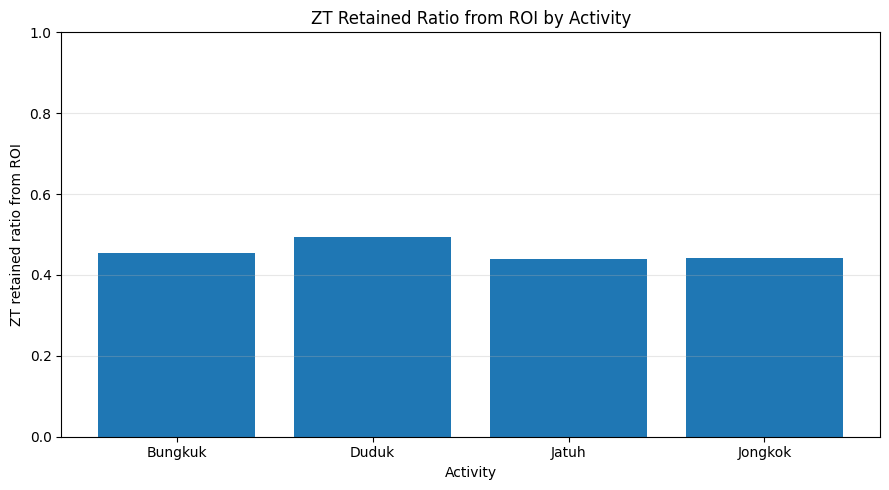

Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/figures/zt_retained_ratio_by_activity.png


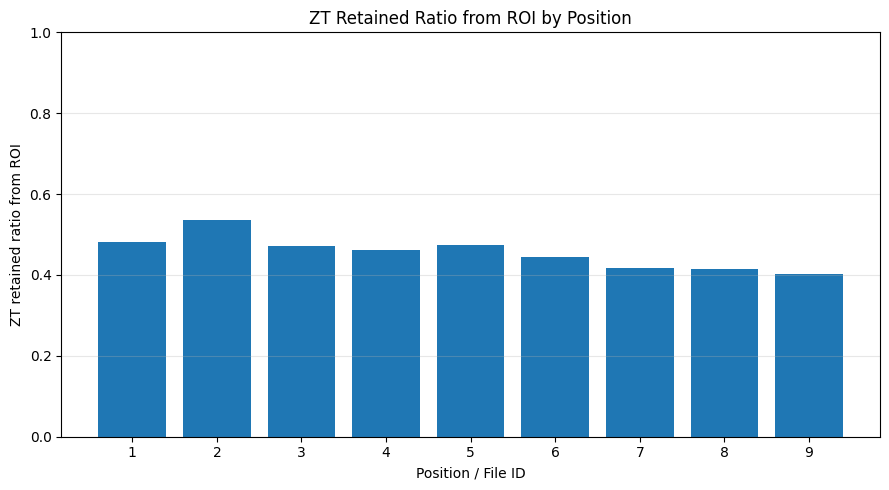

Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/figures/zt_retained_ratio_by_position.png


In [10]:
# Cell 10 - Visualisasi retained ratio per activity dan position

plt.figure(figsize=(9, 5))
plt.bar(activity_diag["activity"], activity_diag["zt_retained_ratio_from_roi_weighted"])
plt.ylim(0, 1)
plt.xlabel("Activity")
plt.ylabel("ZT retained ratio from ROI")
plt.title("ZT Retained Ratio from ROI by Activity")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "zt_retained_ratio_by_activity.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Saved: {fig_path}")


plt.figure(figsize=(9, 5))
plt.bar(position_diag["file_id"].astype(str), position_diag["zt_retained_ratio_from_roi_weighted"])
plt.ylim(0, 1)
plt.xlabel("Position / File ID")
plt.ylabel("ZT retained ratio from ROI")
plt.title("ZT Retained Ratio from ROI by Position")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "zt_retained_ratio_by_position.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Saved: {fig_path}")

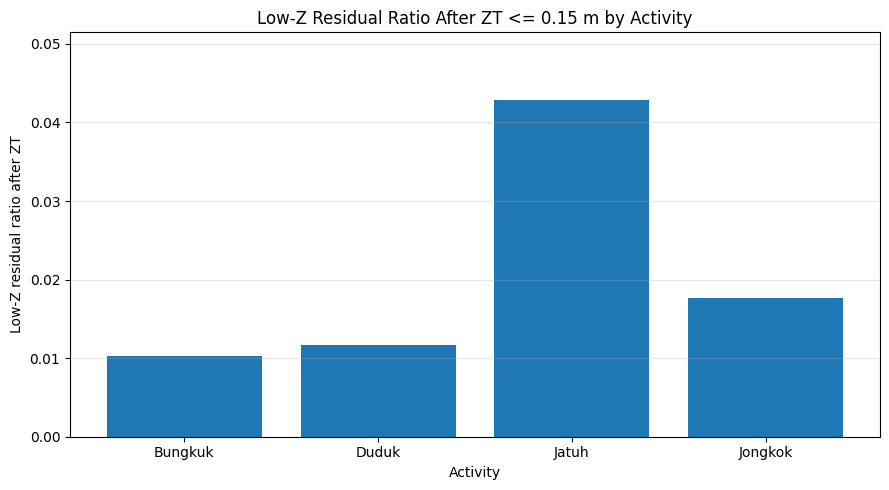

Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/figures/low_z_residual_ratio_by_activity.png


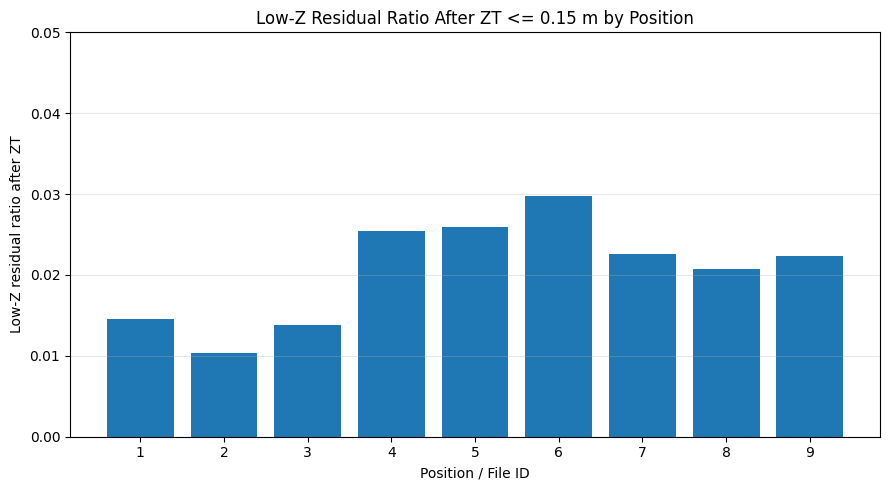

Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/figures/low_z_residual_ratio_by_position.png


In [11]:
# Cell 11 - Visualisasi low-Z residual spread

plt.figure(figsize=(9, 5))
plt.bar(activity_diag["activity"], activity_diag["zt_low_z_residual_ratio_mean"])
plt.ylim(0, max(0.05, activity_diag["zt_low_z_residual_ratio_mean"].max() * 1.2))
plt.xlabel("Activity")
plt.ylabel("Low-Z residual ratio after ZT")
plt.title(f"Low-Z Residual Ratio After ZT <= {LOW_Z_RESIDUAL_LIMIT:.2f} m by Activity")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "low_z_residual_ratio_by_activity.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Saved: {fig_path}")


plt.figure(figsize=(9, 5))
plt.bar(position_diag["file_id"].astype(str), position_diag["zt_low_z_residual_ratio_mean"])
plt.ylim(0, max(0.05, position_diag["zt_low_z_residual_ratio_mean"].max() * 1.2))
plt.xlabel("Position / File ID")
plt.ylabel("Low-Z residual ratio after ZT")
plt.title(f"Low-Z Residual Ratio After ZT <= {LOW_Z_RESIDUAL_LIMIT:.2f} m by Position")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "low_z_residual_ratio_by_position.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Saved: {fig_path}")

In [12]:
# Cell 12 - Diagnostik per frame dari file output

frame_diag_records = []

for _, row in tqdm(manifest_df[manifest_df["roi_exists"] & manifest_df["zt_exists"]].iterrows(),
                   total=int((manifest_df["roi_exists"] & manifest_df["zt_exists"]).sum()),
                   desc="Diagnosing frames"):

    roi_df, roi_err = safe_read_csv(row["roi_path"])
    zt_df, zt_err = safe_read_csv(row["zt_path"])

    if roi_df is None or "frame_id" not in roi_df.columns:
        continue

    roi_frame_counts = roi_df.groupby("frame_id").size().rename("roi_points").reset_index()

    if zt_df is not None and len(zt_df) > 0 and "frame_id" in zt_df.columns:
        zt_frame_counts = zt_df.groupby("frame_id").size().rename("zt_points").reset_index()
    else:
        zt_frame_counts = pd.DataFrame({"frame_id": roi_frame_counts["frame_id"], "zt_points": 0})

    merged = roi_frame_counts.merge(zt_frame_counts, on="frame_id", how="left")
    merged["zt_points"] = merged["zt_points"].fillna(0).astype(int)

    for _, fr in merged.iterrows():
        frame_id = fr["frame_id"]
        frame_roi = roi_df[roi_df["frame_id"] == frame_id]

        if zt_df is not None and len(zt_df) > 0 and "frame_id" in zt_df.columns:
            frame_zt = zt_df[zt_df["frame_id"] == frame_id]
        else:
            frame_zt = pd.DataFrame(columns=roi_df.columns)

        low_zt = frame_zt[frame_zt["Z_level"] <= LOW_Z_RESIDUAL_LIMIT] if len(frame_zt) > 0 else frame_zt

        x_min, x_max, x_range = safe_range(frame_zt["X_corr"]) if len(frame_zt) > 0 else (np.nan, np.nan, np.nan)
        y_min, y_max, y_range = safe_range(frame_zt["Y_corr"]) if len(frame_zt) > 0 else (np.nan, np.nan, np.nan)
        z_min, z_max, z_range = safe_range(frame_zt["Z_level"]) if len(frame_zt) > 0 else (np.nan, np.nan, np.nan)

        lx_min, lx_max, lx_range = safe_range(low_zt["X_corr"]) if len(low_zt) > 0 else (np.nan, np.nan, np.nan)
        ly_min, ly_max, ly_range = safe_range(low_zt["Y_corr"]) if len(low_zt) > 0 else (np.nan, np.nan, np.nan)

        frame_diag_records.append({
            "split": row["split"],
            "room": row["room"],
            "activity": row["activity"],
            "subject": row["subject"],
            "file_id": row["file_id"],
            "rel_path": str(row["rel_path"]),
            "frame_id": frame_id,

            "roi_points": int(fr["roi_points"]),
            "zt_points": int(fr["zt_points"]),
            "zt_retained_ratio_from_roi": safe_ratio(int(fr["zt_points"]), int(fr["roi_points"])),

            "empty_after_zt": int(int(fr["zt_points"]) == 0),

            "zt_x_min": x_min,
            "zt_x_max": x_max,
            "zt_x_range": x_range,
            "zt_y_min": y_min,
            "zt_y_max": y_max,
            "zt_y_range": y_range,
            "zt_z_min": z_min,
            "zt_z_max": z_max,
            "zt_z_range": z_range,

            "low_z_residual_count": int(len(low_zt)),
            "low_z_residual_ratio": safe_ratio(len(low_zt), len(frame_zt)) if len(frame_zt) > 0 else np.nan,
            "low_z_x_range": lx_range,
            "low_z_y_range": ly_range,
        })

frame_diag_df = pd.DataFrame(frame_diag_records)

frame_diag_path = DIAG_DIR / "gc_zt_frame_diagnostic.csv"
frame_diag_df.to_csv(frame_diag_path, index=False)

print("===== FRAME DIAGNOSTIC SAVED =====")
print(f"Records: {len(frame_diag_df):,}")
print(frame_diag_path)

display(frame_diag_df.head())

Diagnosing frames:   0%|          | 0/792 [00:00<?, ?it/s]

===== FRAME DIAGNOSTIC SAVED =====
Records: 47,375
/media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_frame_diagnostic.csv


,split,room,activity,subject,file_id,rel_path,frame_id,roi_points,zt_points,zt_retained_ratio_from_roi,...,zt_y_min,zt_y_max,zt_y_range,zt_z_min,zt_z_max,zt_z_range,low_z_residual_count,low_z_residual_ratio,low_z_x_range,low_z_y_range
0,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,0,2498,1477,0.591273,...,0.0,1.128,1.128,0.128147,1.577881,1.449734,1,0.000677,0.000000,0.000
1,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,1,2470,1448,0.586235,...,0.0,1.046,1.046,0.162232,1.587849,1.425617,0,0.000000,NaN,NaN
2,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,2,2479,1457,0.587737,...,0.0,1.089,1.089,0.127214,1.579793,1.452579,1,0.000686,0.000000,0.000
3,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,3,2497,1471,0.589107,...,0.0,1.072,1.072,0.096432,1.592896,1.496464,1,0.000680,0.000000,0.000
4,development,development,Bungkuk,Adelia,1,Dataset Development/Bungkuk/Adelia/1.csv,4,2488,1466,0.589228,...,0.0,1.071,1.071,0.141622,1.588534,1.446912,2,0.001364,0.011415,0.008


In [13]:
# Cell 13 - Summary empty frame ratio

frame_activity_summary = frame_diag_df.groupby("activity").agg(
    n_frames=("frame_id", "count"),
    empty_after_zt_ratio=("empty_after_zt", "mean"),
    zt_retained_ratio_mean=("zt_retained_ratio_from_roi", "mean"),
    zt_points_mean=("zt_points", "mean"),
    zt_z_range_mean=("zt_z_range", "mean"),
    low_z_residual_ratio_mean=("low_z_residual_ratio", "mean"),
).reset_index()

frame_position_summary = frame_diag_df.groupby("file_id").agg(
    n_frames=("frame_id", "count"),
    empty_after_zt_ratio=("empty_after_zt", "mean"),
    zt_retained_ratio_mean=("zt_retained_ratio_from_roi", "mean"),
    zt_points_mean=("zt_points", "mean"),
    zt_z_range_mean=("zt_z_range", "mean"),
    low_z_residual_ratio_mean=("low_z_residual_ratio", "mean"),
).reset_index()

frame_subject_summary = frame_diag_df.groupby(["split", "room", "subject"]).agg(
    n_frames=("frame_id", "count"),
    empty_after_zt_ratio=("empty_after_zt", "mean"),
    zt_retained_ratio_mean=("zt_retained_ratio_from_roi", "mean"),
    zt_points_mean=("zt_points", "mean"),
    zt_z_range_mean=("zt_z_range", "mean"),
    low_z_residual_ratio_mean=("low_z_residual_ratio", "mean"),
).reset_index()

frame_activity_path = DIAG_DIR / "gc_zt_frame_summary_by_activity.csv"
frame_position_path = DIAG_DIR / "gc_zt_frame_summary_by_position.csv"
frame_subject_path = DIAG_DIR / "gc_zt_frame_summary_by_subject.csv"

frame_activity_summary.to_csv(frame_activity_path, index=False)
frame_position_summary.to_csv(frame_position_path, index=False)
frame_subject_summary.to_csv(frame_subject_path, index=False)

print("===== FRAME SUMMARY BY ACTIVITY =====")
display(frame_activity_summary)

print("===== FRAME SUMMARY BY POSITION =====")
display(frame_position_summary)

print("===== WORST SUBJECTS BY EMPTY AFTER ZT =====")
display(frame_subject_summary.sort_values("empty_after_zt_ratio", ascending=False).head(20))

===== FRAME SUMMARY BY ACTIVITY =====


,activity,n_frames,empty_after_zt_ratio,zt_retained_ratio_mean,zt_points_mean,zt_z_range_mean,low_z_residual_ratio_mean
0,Bungkuk,11555,0.0,0.445611,945.296755,1.115426,0.013146
1,Duduk,11574,0.0,0.480428,1054.075082,1.180574,0.013811
2,Jatuh,12465,0.0,0.423183,865.599438,1.022670,0.055521
3,Jongkok,11781,0.0,0.429392,893.115101,1.041216,0.023743


===== FRAME SUMMARY BY POSITION =====


,file_id,n_frames,empty_after_zt_ratio,zt_retained_ratio_mean,zt_points_mean,zt_z_range_mean,low_z_residual_ratio_mean
0,1,5190,0.0,0.472022,1022.213295,1.079058,0.020350
1,2,5268,0.0,0.516183,1185.498481,0.992934,0.016612
2,3,5190,0.0,0.462403,1007.894990,1.060778,0.019129
3,4,5251,0.0,0.451784,940.943439,1.100470,0.032994
4,5,5273,0.0,0.465049,981.691826,1.093623,0.033278
5,6,5258,0.0,0.436666,896.476227,1.105761,0.037341
6,7,5301,0.0,0.405231,819.148463,1.117090,0.029476
7,8,5301,0.0,0.402082,815.038483,1.125826,0.026164
8,9,5343,0.0,0.388200,778.389482,1.119462,0.028282


===== WORST SUBJECTS BY EMPTY AFTER ZT =====


,split,room,subject,n_frames,empty_after_zt_ratio,zt_retained_ratio_mean,zt_points_mean,zt_z_range_mean,low_z_residual_ratio_mean
0,development,development,Adelia,2171,0.0,0.457513,933.786734,1.131658,0.026423
1,development,development,Afi,2118,0.0,0.459171,986.804060,1.074801,0.018082
20,testing,Uncontrolled Room,Rega,2179,0.0,0.504228,1069.218449,1.089336,0.040833
19,testing,Uncontrolled Room,Nana,1887,0.0,0.448170,906.201908,1.101390,0.034526
18,testing,Uncontrolled Room,Naila,1799,0.0,0.436291,874.764314,1.112376,0.029456
17,testing,Uncontrolled Room,Kanaya,2128,0.0,0.431049,867.884398,1.072712,0.028185
16,testing,Controlled Room,Zaira,2290,0.0,0.437180,921.861572,1.083668,0.021188
15,testing,Controlled Room,Rega,2258,0.0,0.442597,946.135075,1.085979,0.023556
14,testing,Controlled Room,Nana,2146,0.0,0.438676,932.630475,1.049982,0.021087
13,testing,Controlled Room,Naila,2098,0.0,0.435987,927.581030,1.051315,0.018003


In [14]:
# Cell 14 - Ambil contoh file paling bermasalah untuk dicek visual/manual

# Ranking file berdasarkan empty_after_zt dan retained ratio rendah
worst_files = file_diag_df.copy()

worst_files["risk_score"] = (
    worst_files["empty_after_zt"].fillna(0) * 3.0
    + (1.0 - worst_files["zt_retained_ratio_from_roi"].fillna(0)) * 1.0
    + worst_files["zt_low_z_residual_ratio"].fillna(0) * 1.0
)

worst_files = worst_files.sort_values("risk_score", ascending=False)

worst_path = DIAG_DIR / "gc_zt_worst_files_for_manual_check.csv"
worst_files.to_csv(worst_path, index=False)

print("===== WORST FILES FOR MANUAL CHECK =====")
display(
    worst_files[
        [
            "split", "room", "activity", "subject", "file_id", "rel_path",
            "raw_points", "roi_points", "zt_points",
            "roi_retained_ratio_from_raw", "zt_retained_ratio_from_roi",
            "zt_low_z_residual_ratio",
            "empty_after_roi", "empty_after_zt",
            "risk_score",
        ]
    ].head(30)
)

print(f"Saved: {worst_path}")

===== WORST FILES FOR MANUAL CHECK =====


,split,room,activity,subject,file_id,rel_path,raw_points,roi_points,zt_points,roi_retained_ratio_from_raw,zt_retained_ratio_from_roi,zt_low_z_residual_ratio,empty_after_roi,empty_after_zt,risk_score
179,development,development,Duduk,Lina,9,Dataset Development/Duduk/Lina/9.csv,1138176,96111,23890,0.084443,0.248567,0.018250,0,0,0.769684
426,development,development,Jatuh,Tsamara,4,Dataset Development/Jatuh/Tsamara/4.csv,1537536,137853,49976,0.089658,0.362531,0.130743,0,0,0.768212
53,development,development,Bungkuk,Eldivo,9,Dataset Development/Bungkuk/Eldivo/9.csv,1098240,93127,23272,0.084797,0.249895,0.017317,0,0,0.767422
42,development,development,Bungkuk,Dilia,7,Dataset Development/Bungkuk/Dilia/7.csv,1138176,95765,24387,0.084139,0.254655,0.017755,0,0,0.763101
431,development,development,Jatuh,Tsamara,9,Dataset Development/Jatuh/Tsamara/9.csv,1457664,130315,40732,0.089400,0.312566,0.073750,0,0,0.761185
429,development,development,Jatuh,Tsamara,7,Dataset Development/Jatuh/Tsamara/7.csv,1537536,138561,42755,0.090119,0.308564,0.065139,0,0,0.756574
430,development,development,Jatuh,Tsamara,8,Dataset Development/Jatuh/Tsamara/8.csv,1417728,127612,40749,0.090012,0.319319,0.068738,0,0,0.749418
43,development,development,Bungkuk,Dilia,8,Dataset Development/Bungkuk/Dilia/8.csv,1277952,111763,30589,0.087455,0.273695,0.015953,0,0,0.742258
368,development,development,Jatuh,Dilia,9,Dataset Development/Jatuh/Dilia/9.csv,1218048,111876,40244,0.091849,0.359720,0.099990,0,0,0.740270
44,development,development,Bungkuk,Dilia,9,Dataset Development/Bungkuk/Dilia/9.csv,978432,84610,23305,0.086475,0.275440,0.015362,0,0,0.739921


Saved: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_worst_files_for_manual_check.csv


In [15]:
# Cell 15 - Plot 3D fixed-axis untuk satu file dan satu frame

import plotly.graph_objects as go


def plot_3d_fixed_axis(df, title, x_col="X_corr", y_col="Y_corr", z_col="Z_level", max_points=8000):
    if df is None or len(df) == 0:
        print(f"No data to plot: {title}")
        return

    if len(df) > max_points:
        plot_df = df.sample(max_points, random_state=42)
    else:
        plot_df = df.copy()

    fig = go.Figure(data=[
        go.Scatter3d(
            x=plot_df[x_col],
            y=plot_df[y_col],
            z=plot_df[z_col],
            mode="markers",
            marker=dict(
                size=2,
                color=plot_df[z_col],
                colorscale="Viridis",
                opacity=0.75,
            )
        )
    ])

    fig.update_layout(
        title=f"{title}<br>Original points: {len(df):,} | Plotted: {len(plot_df):,}",
        scene=dict(
            xaxis=dict(title=x_col, range=[ROI_X_MIN, ROI_X_MAX]),
            yaxis=dict(title=y_col, range=[ROI_Y_MIN, ROI_Y_MAX]),
            zaxis=dict(title=z_col, range=[ROI_Z_MIN, ROI_Z_MAX]),
            aspectmode="manual",
            aspectratio=dict(x=1.5, y=1.5, z=1.0),
        ),
        width=950,
        height=750,
        margin=dict(l=0, r=0, b=0, t=80),
    )

    fig.show()


# ============================================================
# GANTI BAGIAN INI UNTUK CEK FILE TERTENTU
# Contoh rel_path:
# "Dataset Development/Duduk/Dilia/3.csv"
# "Dataset Testing/Controlled Room/Jatuh/Kanaya/1.csv"
# ============================================================

CHECK_REL_PATH = "Dataset Development/Duduk/Dilia/3.csv"
CHECK_FRAME_ID = None  # isi angka frame_id tertentu, atau None untuk semua frame pada file

roi_check_path = GC_ROI_DIR / CHECK_REL_PATH
zt_check_path = GC_ZT_DIR / CHECK_REL_PATH

roi_check_df, roi_err = safe_read_csv(roi_check_path)
zt_check_df, zt_err = safe_read_csv(zt_check_path)

print("ROI path:", roi_check_path)
print("ZT path :", zt_check_path)
print("ROI err :", roi_err)
print("ZT err  :", zt_err)

if CHECK_FRAME_ID is not None:
    if roi_check_df is not None and "frame_id" in roi_check_df.columns:
        roi_plot_df = roi_check_df[roi_check_df["frame_id"] == CHECK_FRAME_ID].copy()
    else:
        roi_plot_df = pd.DataFrame()

    if zt_check_df is not None and "frame_id" in zt_check_df.columns:
        zt_plot_df = zt_check_df[zt_check_df["frame_id"] == CHECK_FRAME_ID].copy()
    else:
        zt_plot_df = pd.DataFrame()
else:
    roi_plot_df = roi_check_df
    zt_plot_df = zt_check_df

plot_3d_fixed_axis(roi_plot_df, f"After GC25 + ROI | {CHECK_REL_PATH} | frame={CHECK_FRAME_ID}")
plot_3d_fixed_axis(zt_plot_df, f"After GC25 + ROI + ZT {Z_GROUND_THRESHOLD:.2f} | {CHECK_REL_PATH} | frame={CHECK_FRAME_ID}")

ROI path: /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/GC25_ROI/Dataset Development/Duduk/Dilia/3.csv
ZT path : /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/GC25_Z080/Dataset Development/Duduk/Dilia/3.csv
ROI err : 
ZT err  : 


In [16]:
# Cell 16 - Final diagnostic decision helper

print("===== FINAL DIAGNOSTIC CHECKLIST =====")

empty_file_ratio = file_diag_df["empty_after_zt"].mean()
empty_frame_ratio = frame_diag_df["empty_after_zt"].mean() if len(frame_diag_df) > 0 else np.nan

mean_zt_retained_file = file_diag_df["zt_retained_ratio_from_roi"].mean()
mean_low_z_residual = file_diag_df["zt_low_z_residual_ratio"].mean()

print(f"Empty file ratio after ZT        : {empty_file_ratio:.4f}")
print(f"Empty frame ratio after ZT       : {empty_frame_ratio:.4f}")
print(f"Mean ZT retained ratio from ROI  : {mean_zt_retained_file:.4f}")
print(f"Mean low-Z residual after ZT     : {mean_low_z_residual:.4f}")

print("\nInterpretasi awal:")

if empty_frame_ratio > 0.20:
    print("- WARNING: Empty frame ratio setelah ZT > 20%. Threshold/ROI perlu dicek serius.")
elif empty_frame_ratio > 0.05:
    print("- CAUTION: Empty frame ratio setelah ZT > 5%. Cek activity/position yang bermasalah.")
else:
    print("- OK: Empty frame ratio setelah ZT relatif rendah.")

if mean_zt_retained_file < 0.10:
    print("- WARNING: Rata-rata titik tersisa setelah ZT sangat rendah (<10% dari ROI). ZT mungkin agresif.")
elif mean_zt_retained_file < 0.30:
    print("- CAUTION: Rata-rata titik tersisa setelah ZT cukup rendah. Perlu cek visual.")
else:
    print("- OK: Retained ratio setelah ZT masih cukup masuk akal.")

if mean_low_z_residual > 0.30:
    print("- WARNING: Low-Z residual masih tinggi. Threshold 0.08 mungkin belum cukup membersihkan ground.")
elif mean_low_z_residual > 0.10:
    print("- CAUTION: Low-Z residual sedang. Cek per activity/position.")
else:
    print("- OK: Low-Z residual relatif rendah.")

print("\nFile output penting:")
print(f"- {file_diag_path}")
print(f"- {frame_diag_path}")
print(f"- {activity_diag_path}")
print(f"- {position_diag_path}")
print(f"- {problem_path}")
print(f"- {worst_path}")

===== FINAL DIAGNOSTIC CHECKLIST =====
Empty file ratio after ZT        : 0.0000
Empty frame ratio after ZT       : 0.0000
Mean ZT retained ratio from ROI  : 0.4548
Mean low-Z residual after ZT     : 0.0206

Interpretasi awal:
- OK: Empty frame ratio setelah ZT relatif rendah.
- OK: Retained ratio setelah ZT masih cukup masuk akal.
- OK: Low-Z residual relatif rendah.

File output penting:
- /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_file_diagnostic.csv
- /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_frame_diagnostic.csv
- /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_diagnostic_by_activity.csv
- /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_diagnostic_by_position.csv
- /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_GC25_Z008/_diagnostics/gc_zt_problem_files.csv
- /media/spell/Spell-lab/Lidar/Preprocessing/Preprocessed_G

Setelah kamu run, fokus ke file ini:

_diagnostics/gc_zt_global_diagnostic.csv

_diagnostics/gc_zt_diagnostic_by_activity.csv

_diagnostics/gc_zt_diagnostic_by_position.csv

_diagnostics/gc_zt_problem_files.csv

_diagnostics/gc_zt_frame_summary_by_activity.csv

_diagnostics/gc_zt_worst_files_for_manual_check.csv

Yang paling penting dicek:

1. empty_after_zt_ratio
   Kalau tinggi, threshold 0.08 mungkin terlalu agresif.

2. zt_retained_ratio_from_roi
   Kalau terlalu rendah, banyak titik hilang setelah Z-threshold.

3. zt_low_z_residual_ratio
   Kalau tinggi, lantai masih banyak tersisa meski sudah threshold 0.08.

4. zt_low_z_x_range dan zt_low_z_y_range
   Kalau besar, sisa titik rendah menyebar luas, kemungkinan residual lantai.
   Kalau kecil, kemungkinan sisa titik rendah hanya bagian kaki/subjek.

5. activity Jatuh dan Jongkok
   Ini paling penting untuk melihat apakah tubuh rendah ikut terlalu banyak terpotong.